# UCI HAR Dataset 기반 CNN + Transformer 인간 활동 인식 분류

## 결과 분석
Model
- CNN2 + Transformer1: 93.62%
- CNN3 + Transformer1: 92.87%
- CNN3 + Transformer2: 94.27%

CNN3 + Transformer2 모델이 정확도 94.27%로 가장 높은 성능을 보였다.

CNN block을 추가하는 것만으로는 성능이 향상되지 않았지만, Transformer block을 2개로 늘렸을 때 성능이 개선되었다.

따라서 Transformer를 통한 timestep 간 관계 학습이 중요한 것을 보여준다.

In [3]:
# 라이브러리 import
import os
import random
import numpy as np
import tensorflow as tf # Transformer Encoder 모델 구현을 위한 TensorFlow 라이브러리
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Reproducibility

# train/validation 분할, 데이터 shuffle, 모델 초기 가중치와 dropout
# 랜덤 요소를 고정하여 실험 결과를 재현 가능
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.environ["PYTHONHASHSEED"] = str(SEED)

In [6]:
# Locate UCI-HAR Dataset

def find_uci_har_root():
    candidate_roots = [
        Path("/content/UCI HAR Dataset"),
        Path("/content/drive/MyDrive/UCI HAR Dataset"),
        Path("/content/drive/MyDrive/Colab Notebooks/UCI HAR Dataset"),
    ]

    for root in candidate_roots:
        if root.exists():
            return root

    for p in Path("/content").rglob("UCI HAR Dataset"):
        if p.is_dir():
            return p

    raise FileNotFoundError(
        "UCI HAR Dataset 폴더를 찾지 못했습니다. "
        "Colab의 /content 또는 Google Drive 안에 'UCI HAR Dataset' 폴더를 두십시오."
    )

DATA_ROOT = find_uci_har_root()
print("Dataset root:", DATA_ROOT)

Dataset root: /content/drive/MyDrive/UCI HAR Dataset


In [7]:
# Load UCI-HAR Inertial Signals

# 입력으로 사용할 9개의 센서 채널
SIGNAL_NAMES = [
    "body_acc_x",
    "body_acc_y",
    "body_acc_z",
    "body_gyro_x",
    "body_gyro_y",
    "body_gyro_z",
    "total_acc_x",
    "total_acc_y",
    "total_acc_z",
]

# 분류할 6개의 활동 클래스 이름 정의
ACTIVITY_NAMES = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING",
]

def load_signals(split):
    signal_dir = DATA_ROOT / split / "Inertial Signals"

    signals = []

    for name in SIGNAL_NAMES:
        file_path = signal_dir / f"{name}_{split}.txt"
        data = np.loadtxt(file_path)
        signals.append(data)

    # 9개 센서 신호를 합쳐 모델 입력 형태인 (샘플 수, 128 time steps, 9 channels)로 변환
    x = np.stack(signals, axis=-1).astype(np.float32)

    return x

def load_labels(split):
    label_path = DATA_ROOT / split / f"y_{split}.txt"
    y = np.loadtxt(label_path).astype(np.int64)

    # UCI HAR 라벨은 1~6이므로 모델 학습에 맞게 0~5로 변환
    y = y - 1

    return y

X_train = load_signals("train")
y_train = load_labels("train")

X_test = load_signals("test")
y_test = load_labels("test")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (7352, 128, 9)
y_train: (7352,)
X_test : (2947, 128, 9)
y_test : (2947,)


In [8]:
# Normalize using training statistics only

mean = X_train.mean(axis=(0, 1), keepdims=True)
# train 데이터 전체(모든 시간 + 샘플) 기준 평균 계산
std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8
# 표준편차 계산 (0으로 나누는 것 방지 위해 작은 값 추가)

X_train = (X_train - mean) / std
# 평균 0, 분산 1이 되도록 정규화
X_test = (X_test - mean) / std
# train 기준 통계로 test도 동일하게 정규화

In [9]:
# Validation Split

# train 데이터 중 15%를 validation set
VAL_RATIO = 0.15

num_train = X_train.shape[0]
indices = np.arange(num_train)
# 원본 데이터 순서에 따른 편향을 막기 위해 train 인덱스를 랜덤으로 섞음
np.random.shuffle(indices)

# 앞 15%는 validation, 나머지 85%는 실제 train으로 사용
val_size = int(num_train * VAL_RATIO)
val_idx = indices[:val_size]
train_idx = indices[val_size:]

X_val = X_train[val_idx]
y_val = y_train[val_idx]

X_tr = X_train[train_idx]
y_tr = y_train[train_idx]

print("X_tr :", X_tr.shape)
print("X_val:", X_val.shape)



X_tr : (6250, 128, 9)
X_val: (1102, 128, 9)


In [10]:
# TensorFlow Dataset

# 한 번의 학습 step에서 모델에 넣을 샘플 개수
BATCH_SIZE = 128
AUTOTUNE = tf.data.AUTOTUNE

# 학습 데이터를 TensorFlow Dataset 형태로 변환
train_ds = (
    tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
    .shuffle(buffer_size=len(X_tr), seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [11]:
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    BatchNormalization,
    Conv1D,
    Dense,
    Dropout,
    GlobalAveragePooling1D,
    LayerNormalization,
    MaxPooling1D,
    MultiHeadAttention,
    ReLU,
)

# 공통 설정
input_shape = (X_tr.shape[1], X_tr.shape[2])
num_classes = len(ACTIVITY_NAMES)

EPOCHS = 100
embed_dim = 256
num_heads = 8
ff_dim = 512
transformer_drop_rate = 0.1
classifier_drop_rate = 0.5


## Model 1 - CNN 2 blocks + Transformer 1 block


In [12]:
# Model 1: CNN 2 blocks + Transformer 1 block

inputs = Input(shape=input_shape)

# CNN block 1: 원본 센서 시계열에서 짧은 구간의 지역 패턴 추출
x = Conv1D(128, kernel_size=5, padding="same")(inputs)
x = BatchNormalization()(x)
x = ReLU()(x)
x = MaxPooling1D(pool_size=2)(x)

# CNN block 2: 지역 특징을 Transformer가 볼 feature sequence로 변환
x = Conv1D(embed_dim, kernel_size=3, padding="same")(x)
x = BatchNormalization()(x)
x = ReLU()(x)

# Positional Encoding
sequence_length = x.shape[1]
positions = np.arange(sequence_length)[:, np.newaxis]
depths = np.arange(embed_dim)[np.newaxis, :]
angle_rates = 1 / np.power(10000, (2 * (depths // 2)) / np.float32(embed_dim))
angle_rads = positions * angle_rates
pos_encoding = np.zeros((sequence_length, embed_dim), dtype=np.float32)
pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
x = x + tf.constant(pos_encoding[np.newaxis, :, :], dtype=tf.float32)

# Transformer block 1: CNN feature sequence의 timestep 간 관계 학습
attention_output = MultiHeadAttention(
    num_heads=num_heads,
    key_dim=embed_dim // num_heads,
    dropout=transformer_drop_rate,
)(x, x)
attention_output = Dropout(transformer_drop_rate)(attention_output)
x = LayerNormalization(epsilon=1e-6)(x + attention_output)

ffn_output = Dense(ff_dim, activation="relu")(x)
ffn_output = Dropout(transformer_drop_rate)(ffn_output)
ffn_output = Dense(embed_dim)(ffn_output)
ffn_output = Dropout(transformer_drop_rate)(ffn_output)
x = LayerNormalization(epsilon=1e-6)(x + ffn_output)

# Classification head
x = GlobalAveragePooling1D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(classifier_drop_rate)(x)
outputs = Dense(num_classes, activation="softmax")(x)

model_1 = Model(inputs=inputs, outputs=outputs)
model_1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"],
)
model_1.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 128, 128)  │      5,888 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128)  │        512 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 128, 128)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 64, 128)   │          0 │ re_lu[0][0]       │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 64, 256)   │     98,560 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 256)   │      1,024 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 64, 256)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 256)   │          0 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 256)   │    263,168 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 256)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 256)   │          0 │ add[0][0],        │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 64, 256)   │        512 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64, 512)   │    131,584 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64, 512)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64, 256)   │    131,328 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64, 256)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 64, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 256)   │        512 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                 

 Total params: 666,758 (2.54 MB)

 Trainable params: 665,990 (2.54 MB)

 Non-trainable params: 768 (3.00 KB)

In [13]:
checkpoint_path_1 = "/content/best_cnn2_transformer1_uci_har.keras"
callbacks_1 = [
    tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path_1,
        monitor="val_sparse_categorical_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_sparse_categorical_accuracy",
        patience=20,
        mode="max",
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1,
    ),
]

history_1 = model_1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_1,
    verbose=1,
)


Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - loss: 0.7551 - sparse_categorical_accuracy: 0.7095
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.91289, saving model to /content/best_cnn2_transformer1_uci_har.keras

Epoch 1: finished saving model to /content/best_cnn2_transformer1_uci_har.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 29s 290ms/step - loss: 0.4200 - sparse_categorical_accuracy: 0.8390 - val_loss: 0.2512 - val_sparse_categorical_accuracy: 0.9129 - learning_rate: 0.0010
Epoch 2/100
47/49 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1551 - sparse_categorical_accuracy: 0.9381
Epoch 2: val_sparse_categorical_accuracy did not improve from 0.91289
49/49 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - loss: 0.1466 - sparse_categorical_accuracy: 0.9402 - val_loss: 0.2144 - val_sparse_categorical_accuracy: 0.9102 - learning_rate: 0.0010
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1192 - sparse_categorical_accuracy: 0.9508
Epoch 3: val_sparse_categorical_accuracy

In [14]:
best_model_1 = tf.keras.models.load_model(checkpoint_path_1)

test_loss_1, test_acc_1 = best_model_1.evaluate(test_ds, verbose=0)
y_prob_1 = best_model_1.predict(test_ds)
y_pred_1 = np.argmax(y_prob_1, axis=1)

accuracy_1 = accuracy_score(y_test, y_pred_1)
macro_f1_1 = f1_score(y_test, y_pred_1, average="macro")
weighted_f1_1 = f1_score(y_test, y_pred_1, average="weighted")

print("================ Model 1: CNN2 + Transformer1 ================")
print(f"Test Loss   : {test_loss_1:.4f}")
print(f"Accuracy    : {accuracy_1:.4f}")
print(f"Macro-F1    : {macro_f1_1:.4f}")
print(f"Weighted-F1 : {weighted_f1_1:.4f}")
print()
print(classification_report(y_test, y_pred_1, target_names=ACTIVITY_NAMES, digits=4))


24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step
================ Model 1: CNN2 + Transformer1 ================
Test Loss   : 0.5056
Accuracy    : 0.9362
Macro-F1    : 0.9363
Weighted-F1 : 0.9357

                    precision    recall  f1-score   support

           WALKING     0.9589    0.9879    0.9732       496
  WALKING_UPSTAIRS     0.9863    0.9151    0.9493       471
WALKING_DOWNSTAIRS     0.9477    0.9929    0.9698       420
           SITTING     0.8941    0.8086    0.8492       491
          STANDING     0.8529    0.9154    0.8830       532
            LAYING     0.9871    1.0000    0.9935       537

          accuracy                         0.9362      2947
         macro avg     0.9378    0.9366    0.9363      2947
      weighted avg     0.9369    0.9362    0.9357      2947



## Model 2 - CNN 3 blocks + Transformer 1 block


In [15]:
# Model 2: CNN 3 blocks + Transformer 1 block

inputs = Input(shape=input_shape)

# CNN block 1
x = Conv1D(128, kernel_size=5, padding="same")(inputs)
x = BatchNormalization()(x)
x = ReLU()(x)

# CNN block 2
x = Conv1D(128, kernel_size=3, padding="same")(x)
x = BatchNormalization()(x)
x = ReLU()(x)
x = MaxPooling1D(pool_size=2)(x)

# CNN block 3
x = Conv1D(embed_dim, kernel_size=3, padding="same")(x)
x = BatchNormalization()(x)
x = ReLU()(x)

# Positional Encoding
sequence_length = x.shape[1]
positions = np.arange(sequence_length)[:, np.newaxis]
depths = np.arange(embed_dim)[np.newaxis, :]
angle_rates = 1 / np.power(10000, (2 * (depths // 2)) / np.float32(embed_dim))
angle_rads = positions * angle_rates
pos_encoding = np.zeros((sequence_length, embed_dim), dtype=np.float32)
pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
x = x + tf.constant(pos_encoding[np.newaxis, :, :], dtype=tf.float32)

# Transformer block 1
attention_output = MultiHeadAttention(
    num_heads=num_heads,
    key_dim=embed_dim // num_heads,
    dropout=transformer_drop_rate,
)(x, x)
attention_output = Dropout(transformer_drop_rate)(attention_output)
x = LayerNormalization(epsilon=1e-6)(x + attention_output)

ffn_output = Dense(ff_dim, activation="relu")(x)
ffn_output = Dropout(transformer_drop_rate)(ffn_output)
ffn_output = Dense(embed_dim)(ffn_output)
ffn_output = Dropout(transformer_drop_rate)(ffn_output)
x = LayerNormalization(epsilon=1e-6)(x + ffn_output)

# Classification head
x = GlobalAveragePooling1D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(classifier_drop_rate)(x)
outputs = Dense(num_classes, activation="softmax")(x)

model_2 = Model(inputs=inputs, outputs=outputs)
model_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"],
)
model_2.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 128, 128)  │      5,888 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 128, 128)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 128, 128)  │     49,280 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 128, 128)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 64, 128)   │          0 │ re_lu_3[0][0]     │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 64, 256)   │     98,560 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 256)   │      1,024 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 64, 256)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 64, 256)   │          0 │ re_lu_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 256)   │    263,168 │ add_3[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 64, 256)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 64, 256)   │          0 │ add_3[0][0],      │
│                     │                   │            │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 256)   │        512 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64, 512)   │    131,584 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 64, 512)   │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64, 256)   │    131,328 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 64, 256)   │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 64, 256)   │          0 │ layer_normalizat

 Total params: 716,550 (2.73 MB)

 Trainable params: 715,526 (2.73 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [16]:
checkpoint_path_2 = "/content/best_cnn3_transformer1_uci_har.keras"
callbacks_2 = [
    tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path_2,
        monitor="val_sparse_categorical_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_sparse_categorical_accuracy",
        patience=20,
        mode="max",
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1,
    ),
]

history_2 = model_2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_2,
    verbose=1,
)


Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - loss: 0.8136 - sparse_categorical_accuracy: 0.6784
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.91016, saving model to /content/best_cnn3_transformer1_uci_har.keras

Epoch 1: finished saving model to /content/best_cnn3_transformer1_uci_har.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 24s 230ms/step - loss: 0.4444 - sparse_categorical_accuracy: 0.8224 - val_loss: 0.2645 - val_sparse_categorical_accuracy: 0.9102 - learning_rate: 0.0010
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1398 - sparse_categorical_accuracy: 0.9509
Epoch 2: val_sparse_categorical_accuracy improved from 0.91016 to 0.92650, saving model to /content/best_cnn3_transformer1_uci_har.keras

Epoch 2: finished saving model to /content/best_cnn3_transformer1_uci_har.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.1499 - sparse_categorical_accuracy: 0.9421 - val_loss: 0.2113 - val_sparse_categorical_accuracy: 0.9265 - learning_rate: 0.001

In [17]:
best_model_2 = tf.keras.models.load_model(checkpoint_path_2)

test_loss_2, test_acc_2 = best_model_2.evaluate(test_ds, verbose=0)
y_prob_2 = best_model_2.predict(test_ds)
y_pred_2 = np.argmax(y_prob_2, axis=1)

accuracy_2 = accuracy_score(y_test, y_pred_2)
macro_f1_2 = f1_score(y_test, y_pred_2, average="macro")
weighted_f1_2 = f1_score(y_test, y_pred_2, average="weighted")

print("================ Model 2: CNN3 + Transformer1 ================")
print(f"Test Loss   : {test_loss_2:.4f}")
print(f"Accuracy    : {accuracy_2:.4f}")
print(f"Macro-F1    : {macro_f1_2:.4f}")
print(f"Weighted-F1 : {weighted_f1_2:.4f}")
print()
print(classification_report(y_test, y_pred_2, target_names=ACTIVITY_NAMES, digits=4))


24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step
================ Model 2: CNN3 + Transformer1 ================
Test Loss   : 0.6468
Accuracy    : 0.9287
Macro-F1    : 0.9283
Weighted-F1 : 0.9284

                    precision    recall  f1-score   support

           WALKING     0.9956    0.9173    0.9549       496
  WALKING_UPSTAIRS     0.9608    0.9363    0.9484       471
WALKING_DOWNSTAIRS     0.8929    0.9929    0.9402       420
           SITTING     0.8834    0.8024    0.8410       491
          STANDING     0.8574    0.9267    0.8907       532
            LAYING     0.9890    1.0000    0.9944       537

          accuracy                         0.9287      2947
         macro avg     0.9298    0.9293    0.9283      2947
      weighted avg     0.9306    0.9287    0.9284      2947



## Model 3 - CNN 3 blocks + Transformer 2 blocks


In [18]:
# Model 3: CNN 3 blocks + Transformer 2 blocks

inputs = Input(shape=input_shape)

# CNN block 1
x = Conv1D(128, kernel_size=5, padding="same")(inputs)
x = BatchNormalization()(x)
x = ReLU()(x)

# CNN block 2
x = Conv1D(128, kernel_size=3, padding="same")(x)
x = BatchNormalization()(x)
x = ReLU()(x)
x = MaxPooling1D(pool_size=2)(x)

# CNN block 3
x = Conv1D(embed_dim, kernel_size=3, padding="same")(x)
x = BatchNormalization()(x)
x = ReLU()(x)

# Positional Encoding
sequence_length = x.shape[1]
positions = np.arange(sequence_length)[:, np.newaxis]
depths = np.arange(embed_dim)[np.newaxis, :]
angle_rates = 1 / np.power(10000, (2 * (depths // 2)) / np.float32(embed_dim))
angle_rads = positions * angle_rates
pos_encoding = np.zeros((sequence_length, embed_dim), dtype=np.float32)
pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
x = x + tf.constant(pos_encoding[np.newaxis, :, :], dtype=tf.float32)

# Transformer block 1
attention_output = MultiHeadAttention(
    num_heads=num_heads,
    key_dim=embed_dim // num_heads,
    dropout=transformer_drop_rate,
)(x, x)
attention_output = Dropout(transformer_drop_rate)(attention_output)
x = LayerNormalization(epsilon=1e-6)(x + attention_output)

ffn_output = Dense(ff_dim, activation="relu")(x)
ffn_output = Dropout(transformer_drop_rate)(ffn_output)
ffn_output = Dense(embed_dim)(ffn_output)
ffn_output = Dropout(transformer_drop_rate)(ffn_output)
x = LayerNormalization(epsilon=1e-6)(x + ffn_output)

# Transformer block 2
attention_output = MultiHeadAttention(
    num_heads=num_heads,
    key_dim=embed_dim // num_heads,
    dropout=transformer_drop_rate,
)(x, x)
attention_output = Dropout(transformer_drop_rate)(attention_output)
x = LayerNormalization(epsilon=1e-6)(x + attention_output)

ffn_output = Dense(ff_dim, activation="relu")(x)
ffn_output = Dropout(transformer_drop_rate)(ffn_output)
ffn_output = Dense(embed_dim)(ffn_output)
ffn_output = Dropout(transformer_drop_rate)(ffn_output)
x = LayerNormalization(epsilon=1e-6)(x + ffn_output)

# Classification head
x = GlobalAveragePooling1D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(classifier_drop_rate)(x)
outputs = Dense(num_classes, activation="softmax")(x)

model_3 = Model(inputs=inputs, outputs=outputs)
model_3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"],
)
model_3.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 128, 128)  │      5,888 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_5 (ReLU)      │ (None, 128, 128)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 128, 128)  │     49,280 │ re_lu_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_6 (ReLU)      │ (None, 128, 128)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 64, 128)   │          0 │ re_lu_6[0][0]     │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 64, 256)   │     98,560 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 256)   │      1,024 │ conv1d_7[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_7 (ReLU)      │ (None, 64, 256)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 64, 256)   │          0 │ re_lu_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 256)   │    263,168 │ add_6[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_6[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 64, 256)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 64, 256)   │          0 │ add_6[0][0],      │
│                     │                   │            │ dropout_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 256)   │        512 │ add_7[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64, 512)   │    131,584 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 64, 512)   │          0 │ dense_8[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64, 256)   │    131,328 │ dropout_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 64, 256)   │          0 │ dense_9[0][0]   

 Total params: 1,243,654 (4.74 MB)

 Trainable params: 1,242,630 (4.74 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [19]:
checkpoint_path_3 = "/content/best_cnn3_transformer2_uci_har.keras"
callbacks_3 = [
    tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path_3,
        monitor="val_sparse_categorical_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_sparse_categorical_accuracy",
        patience=20,
        mode="max",
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1,
    ),
]

history_3 = model_3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_3,
    verbose=1,
)


Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - loss: 0.7949 - sparse_categorical_accuracy: 0.6855
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.82214, saving model to /content/best_cnn3_transformer2_uci_har.keras

Epoch 1: finished saving model to /content/best_cnn3_transformer2_uci_har.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 35s 343ms/step - loss: 0.4398 - sparse_categorical_accuracy: 0.8266 - val_loss: 0.4075 - val_sparse_categorical_accuracy: 0.8221 - learning_rate: 0.0010
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.2049 - sparse_categorical_accuracy: 0.9269
Epoch 2: val_sparse_categorical_accuracy did not improve from 0.82214
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.1798 - sparse_categorical_accuracy: 0.9334 - val_loss: 0.7315 - val_sparse_categorical_accuracy: 0.7840 - learning_rate: 0.0010
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.1474 - sparse_categorical_accuracy: 0.9426
Epoch 3: val_sparse_categorical_accuracy 

In [20]:
best_model_3 = tf.keras.models.load_model(checkpoint_path_3)

test_loss_3, test_acc_3 = best_model_3.evaluate(test_ds, verbose=0)
y_prob_3 = best_model_3.predict(test_ds)
y_pred_3 = np.argmax(y_prob_3, axis=1)

accuracy_3 = accuracy_score(y_test, y_pred_3)
macro_f1_3 = f1_score(y_test, y_pred_3, average="macro")
weighted_f1_3 = f1_score(y_test, y_pred_3, average="weighted")

print("================ Model 3: CNN3 + Transformer2 ================")
print(f"Test Loss   : {test_loss_3:.4f}")
print(f"Accuracy    : {accuracy_3:.4f}")
print(f"Macro-F1    : {macro_f1_3:.4f}")
print(f"Weighted-F1 : {weighted_f1_3:.4f}")
print()
print(classification_report(y_test, y_pred_3, target_names=ACTIVITY_NAMES, digits=4))


24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step
================ Model 3: CNN3 + Transformer2 ================
Test Loss   : 0.4542
Accuracy    : 0.9427
Macro-F1    : 0.9426
Weighted-F1 : 0.9423

                    precision    recall  f1-score   support

           WALKING     0.9896    0.9637    0.9765       496
  WALKING_UPSTAIRS     0.9631    0.9427    0.9528       471
WALKING_DOWNSTAIRS     0.9579    0.9762    0.9670       420
           SITTING     0.9029    0.8147    0.8565       491
          STANDING     0.8613    0.9568    0.9065       532
            LAYING     0.9926    1.0000    0.9963       537

          accuracy                         0.9427      2947
         macro avg     0.9446    0.9423    0.9426      2947
      weighted avg     0.9438    0.9427    0.9423      2947



================ Final Comparison ================


,Model,Test Loss,Accuracy,Macro-F1,Weighted-F1
0,CNN2 + Transformer1,0.505640,0.936206,0.936344,0.935664
1,CNN3 + Transformer1,0.646827,0.928741,0.928273,0.928403
2,CNN3 + Transformer2,0.454182,0.942654,0.942600,0.942337


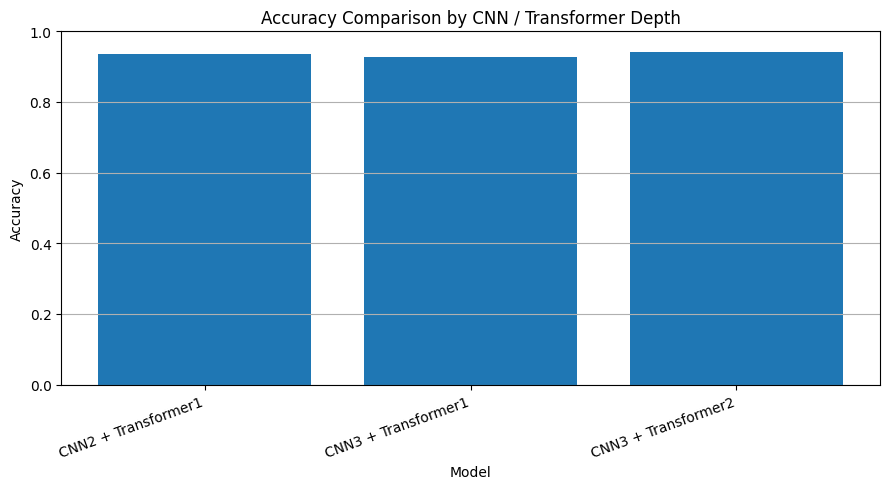

In [21]:
result_df = pd.DataFrame([
    {
        "Model": "CNN2 + Transformer1",
        "Test Loss": test_loss_1,
        "Accuracy": accuracy_1,
        "Macro-F1": macro_f1_1,
        "Weighted-F1": weighted_f1_1,
    },
    {
        "Model": "CNN3 + Transformer1",
        "Test Loss": test_loss_2,
        "Accuracy": accuracy_2,
        "Macro-F1": macro_f1_2,
        "Weighted-F1": weighted_f1_2,
    },
    {
        "Model": "CNN3 + Transformer2",
        "Test Loss": test_loss_3,
        "Accuracy": accuracy_3,
        "Macro-F1": macro_f1_3,
        "Weighted-F1": weighted_f1_3,
    },
])

print("================ Final Comparison ================")
display(result_df)

plt.figure(figsize=(9, 5))
plt.bar(result_df["Model"], result_df["Accuracy"])
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison by CNN / Transformer Depth")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()
